**Ruiqi Liu**  
**CS6220**  
**Assignment 8**  
**3/6/2025**  

---



## 1. Data Preparation
### (a) Feature Selection
In this step, we load the dataset and perform preprocessing which includes:
- Handling missing values
- Normalizing the numerical features
- Encoding categorical variables

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
data = pd.read_csv("aw_fb_data.csv")

# Display first few rows of the data
print("Initial Data Snapshot:")
print(data.head())

# Handle missing values
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].mean())

# Encode categorical variable 'activity'
if data['activity'].dtype == 'object':
    le = LabelEncoder()
    data['activity'] = le.fit_transform(data['activity'])

# Encode categorical variable 'device'
if data["device"].dtype == "object":
    le_device = LabelEncoder()
    data["device"] = le_device.fit_transform(data["device"])

# Normalize the numeric features
scaler = StandardScaler()
features = data.drop("activity", axis=1)  # Ensure all are numeric now
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Reassemble the dataframe
data_processed = pd.concat([features_scaled, data["activity"]], axis=1)

print("\nProcessed Data Snapshot:")
print(data_processed.head())


Initial Data Snapshot:
   Unnamed: 0  X1  age  gender  height  weight      steps  hear_rate  \
0           1   1   20       1   168.0    65.4  10.771429  78.531302   
1           2   2   20       1   168.0    65.4  11.475325  78.453390   
2           3   3   20       1   168.0    65.4  12.179221  78.540825   
3           4   4   20       1   168.0    65.4  12.883117  78.628260   
4           5   5   20       1   168.0    65.4  13.587013  78.715695   

    calories  distance  entropy_heart  entropy_setps  resting_heart  \
0   0.344533  0.008327       6.221612       6.116349           59.0   
1   3.287625  0.008896       6.221612       6.116349           59.0   
2   9.484000  0.009466       6.221612       6.116349           59.0   
3  10.154556  0.010035       6.221612       6.116349           59.0   
4  10.825111  0.010605       6.221612       6.116349           59.0   

   corr_heart_steps  norm_heart  intensity_karvonen  sd_norm_heart  \
0          1.000000   19.531302            0.13

### (b) Train-Test Split
Now we split the processed data into training (80%) and testing (20%) sets.

In [3]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
X = data_processed.drop("activity", axis=1)
y = data_processed["activity"]

# Perform an 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (5011, 19)
Testing set size: (1253, 19)


## 2. Decision Trees
### (a) Model Building
We will now train a decision tree classifier. We will report:
- Tree depth
- Number of leaves
- Feature importance
- Accuracy scores on both the training and testing sets


In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train a decision tree classifier with default parameters
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Get the tree depth and number of leaves
tree_depth = dtree.get_depth()
n_leaves = dtree.get_n_leaves()

# Compute accuracy on training and testing data
train_accuracy = accuracy_score(y_train, dtree.predict(X_train))
test_accuracy = accuracy_score(y_test, dtree.predict(X_test))

# Feature importance
feature_importances = pd.Series(dtree.feature_importances_, index=X.columns)

print("Decision Tree Model Building Results:")
print("Tree Depth:", tree_depth)
print("Number of Leaves:", n_leaves)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print("\nFeature Importances:")
print(feature_importances.sort_values(ascending=False))


Decision Tree Model Building Results:
Tree Depth: 25
Number of Leaves: 870
Training Accuracy: 1.0
Testing Accuracy: 0.7893056664006385

Feature Importances:
steps                   0.226274
calories                0.117450
intensity_karvonen      0.073499
corr_heart_steps        0.072844
distance                0.065085
hear_rate               0.062379
sd_norm_heart           0.061247
steps_times_distance    0.051534
Unnamed: 0              0.049148
norm_heart              0.048534
entropy_setps           0.047193
X1                      0.044137
entropy_heart           0.023142
weight                  0.017645
height                  0.016122
age                     0.015781
resting_heart           0.006676
gender                  0.001310
device                  0.000000
dtype: float64


### (b) Model Tuning
- We now generate decision trees with varying depths (from the maximum depth down to 1) and evaluate the performance in terms of accuracy. 
- We will plot training and testing accuracy scores as a function of tree depth. 
- We will also discuss whether overfitting or underfitting occurs and potential ways to address it.

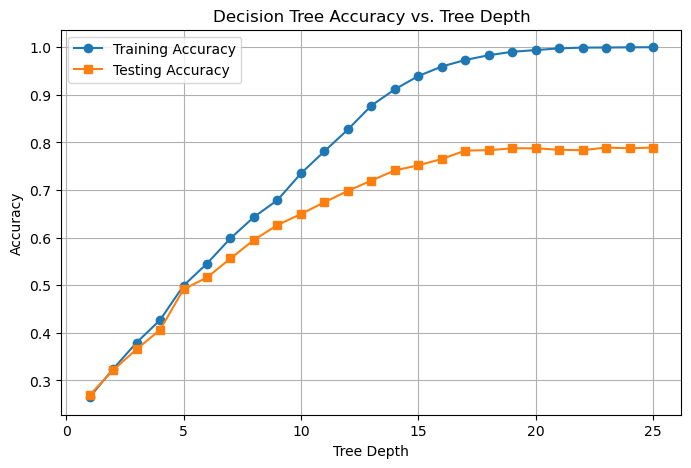

Optimal Tree Depth: 23


In [5]:
import matplotlib.pyplot as plt

# Store accuracy results for different depths
depths = list(range(1, tree_depth + 1))
train_acc = []
test_acc = []

for depth in depths:
    dtree_tuned = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dtree_tuned.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, dtree_tuned.predict(X_train)))
    test_acc.append(accuracy_score(y_test, dtree_tuned.predict(X_test)))

# Plot the accuracy scores
plt.figure(figsize=(8, 5))
plt.plot(depths, train_acc, marker='o', label='Training Accuracy')
plt.plot(depths, test_acc, marker='s', label='Testing Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs. Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

# Determine the optimal depth based on the highest testing accuracy
optimal_depth = depths[test_acc.index(max(test_acc))]
print("Optimal Tree Depth:", optimal_depth)


**Optimal Tree Depth**:  
The optimal tree depth was found to be **23** (i.e., the tree with max_depth=23 achieved the highest test accuracy of approximately 78.93%).

**Overfitting/Underfitting Observations**:  
- **Overfitting**: At deeper tree levels (e.g., near 25), the training accuracy reaches 1.0 while the test accuracy does not improve beyond about 78.93%. This indicates that the model is memorizing the training data.  
- **Underfitting**: With very shallow trees, the model would not capture enough detail, but in our case, the issue is primarily overfitting.

**Addressing Overfitting**:  
- **Pruning or Limiting Depth**: Reducing the maximum depth (e.g., using a depth of 23 or lower) helps to prevent the model from becoming overly complex.  
- **Ensemble Methods**: Using ensemble techniques such as Random Forests or Gradient Boosting can also help reduce variance and improve generalization.


### (c) Visualization
We now visualize the decision tree that achieved the best test accuracy using the Graphviz library. The visualization includes clear feature and class names.


In [6]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# Train a decision tree classifier with the optimal depth found
best_dtree = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
best_dtree.fit(X_train, y_train)

# Export the tree in DOT format
dot_data = export_graphviz(best_dtree, out_file=None, 
                           feature_names=X_train.columns,  
                           class_names=[str(cls) for cls in np.unique(y_train)],  
                           filled=True, rounded=True,  
                           special_characters=True)

# Visualize the decision tree using Graphviz
graph = graphviz.Source(dot_data)
graph.render("decision_tree_best", format="png", cleanup=True)
graph


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.46816 to fit


## 3. K-Nearest Neighbors (KNN)
### (a) Model Building
Next, we build a KNN classifier. We train the model on the training set and report both training and testing accuracy scores.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Train a KNN model with a default k
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Compute accuracy on training and testing data
train_accuracy_knn = accuracy_score(y_train, knn.predict(X_train))
test_accuracy_knn = accuracy_score(y_test, knn.predict(X_test))

print("KNN Model Building Results:")
print("Training Accuracy:", train_accuracy_knn)
print("Testing Accuracy:", test_accuracy_knn)


KNN Model Building Results:
Training Accuracy: 0.8054280582718021
Testing Accuracy: 0.6887470071827614


### (b) Model Tuning
We now generate KNN models by varying the number of neighbors (from 1 to 10) and plot the training and testing accuracy scores as a function of the number of neighbors. We will discuss potential overfitting or underfitting.


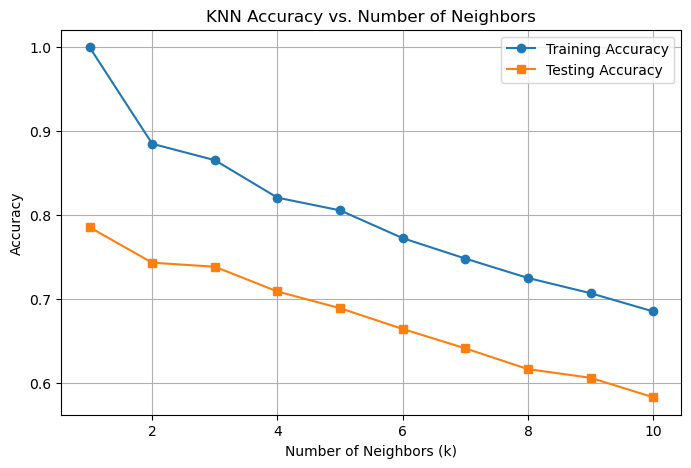

In [8]:
# Store accuracy results for different numbers of neighbors
neighbors = list(range(1, 11))
train_acc_knn = []
test_acc_knn = []

for k in neighbors:
    knn_tuned = KNeighborsClassifier(n_neighbors=k)
    knn_tuned.fit(X_train, y_train)
    train_acc_knn.append(accuracy_score(y_train, knn_tuned.predict(X_train)))
    test_acc_knn.append(accuracy_score(y_test, knn_tuned.predict(X_test)))

# Plot the accuracy scores
plt.figure(figsize=(8, 5))
plt.plot(neighbors, train_acc_knn, marker='o', label='Training Accuracy')
plt.plot(neighbors, test_acc_knn, marker='s', label='Testing Accuracy')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. Number of Neighbors")
plt.legend()
plt.grid(True)
plt.show()


**Observations**:  
- With **k=1**, the training accuracy is nearly perfect (close to 1.0), which indicates overfitting as the model memorizes the training instances.  
- As **k increases** (for example, around k=3 to 5), the training accuracy decreases while the test accuracy improves, suggesting a better balance between bias and variance.  
- For very high values of **k** (approaching 10), the model may underfit, leading to a drop in both training and test accuracy.

**Optimal k Value**:  
The best performance appears to be achieved around **k=3 to k=5**, where the model is less overfitted while still capturing local patterns.

**Addressing Overfitting/Underfitting**:  
- **Cross-Validation**: Use cross-validation to select the optimal k.  
- **Distance Weighting**: Consider weighting neighbors by distance to further mitigate the effects of outliers.


## 4. Logistic Regression
### (a) Model Building
We now train a logistic regression model to predict the type of activity. We will report the training and testing accuracy scores.


In [10]:
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model with default parameters
log_reg = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
log_reg.fit(X_train, y_train)

# Compute accuracy on training and testing data
train_accuracy_lr = accuracy_score(y_train, log_reg.predict(X_train))
test_accuracy_lr = accuracy_score(y_test, log_reg.predict(X_test))

print("Logistic Regression Model Building Results:")
print("Training Accuracy:", train_accuracy_lr)
print("Testing Accuracy:", test_accuracy_lr)


Logistic Regression Model Building Results:
Training Accuracy: 0.34903212931550587
Testing Accuracy: 0.33280127693535516


### (b) Model Tuning
We now tune the logistic regression model by varying the regularization strength (parameter C). We plot training and testing accuracy scores versus the regularization strength and discuss the effect of regularization on the model performance.


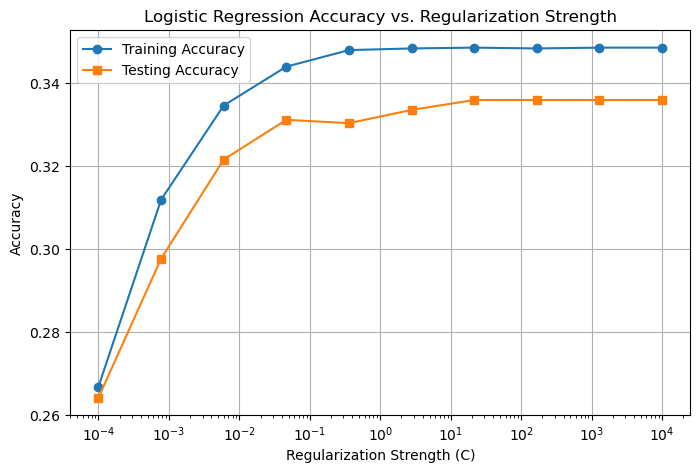

In [11]:
# Define a range of regularization strengths (C values)
C_values = np.logspace(-4, 4, 10)
train_acc_lr = []
test_acc_lr = []

for C in C_values:
    lr_tuned = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000, C=C)
    lr_tuned.fit(X_train, y_train)
    train_acc_lr.append(accuracy_score(y_train, lr_tuned.predict(X_train)))
    test_acc_lr.append(accuracy_score(y_test, lr_tuned.predict(X_test)))

# Plot the accuracy scores
plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_acc_lr, marker='o', label='Training Accuracy')
plt.semilogx(C_values, test_acc_lr, marker='s', label='Testing Accuracy')
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Accuracy")
plt.title("Logistic Regression Accuracy vs. Regularization Strength")
plt.legend()
plt.grid(True)
plt.show()


**Observations**:  
- As the regularization parameter **C** increases (i.e., the regularization strength decreases), the training accuracy rises from around 26% to about 35%.  
- Despite the increase in training accuracy with higher C values, the test accuracy remains low (around 33%), which suggests that even with less regularization, the model struggles to generalize.

**Effect of Regularization**:  
- **Low C (Strong Regularization)**: The model is too simple, leading to underfitting and lower accuracies.  
- **High C (Weak Regularization)**: Allows the model to capture more nuances in the training data, but the gain in training accuracy does not translate into improved test accuracy—indicating that the linear model is inherently limited in capturing the complex relationships in the data.

**Conclusion**:  
Regularization controls model complexity. However, the overall low performance (both training and testing) suggests that the linear logistic regression model does not capture the necessary nonlinearities in the data. More complex models or additional feature engineering would be needed to boost performance.


## 5. Discussion

### (a) Model Comparison
- **Decision Tree**:  
  - Test Accuracy: ~78.93%  
  - Pros: Excellent performance on this dataset and ability to model nonlinear relationships.  
  - Cons: Tends to overfit if not pruned or appropriately constrained.
- **KNN**:  
  - Test Accuracy: ~68.87%  
  - Pros: Simple and intuitive; effective at capturing local structure.  
  - Cons: Sensitive to the choice of k and can be computationally intensive for large datasets.
- **Logistic Regression**:  
  - Test Accuracy: ~33.28%  
  - Pros: Fast and interpretable.  
  - Cons: Linear boundaries are insufficient to capture the complexity of the data, leading to poor performance.

**Overall Best Model**:  
The Decision Tree performs the best due to its flexibility in capturing nonlinear relationships among the sensor measurements.

### (b) Implications and Limitations
**Implications**:
- **Real-World Applications**:  
  - These models can be integrated into wearable devices for real-time activity recognition, offering personalized feedback and health monitoring.
  - High-accuracy models (like the decision tree) can improve the reliability of activity classification in fitness tracking.
  
- **Understanding Data**:  
  - The feature importances from the decision tree help identify which metrics (e.g., steps, calories, intensity) are most influential in classifying activities.

**Limitations**:
- **Overfitting**:  
  - The decision tree, when grown too deep, overfits the training data. This can be addressed by pruning or limiting the tree depth.
- **Model Complexity**:  
  - Logistic regression underperforms because it cannot capture the complex, nonlinear relationships in the data. Advanced feature engineering or more flexible models are necessary.
- **Scalability**:  
  - KNN can be slow during prediction time when scaling to larger datasets.
- **Data Quality**:  
  - The variability and noise in wearable sensor data may affect model performance, requiring robust preprocessing and possibly more diverse training data.

**Addressing Limitations**:
- Utilize ensemble methods (e.g., Random Forests, Gradient Boosting) to reduce overfitting and improve prediction accuracy.
- Apply cross-validation and feature engineering to optimize model parameters.
- Consider alternative algorithms that can balance complexity and interpretability while scaling to larger datasets.
